# House Price Prediction – Capstone Project

**Objective:** Predict house prices (in Lakhs) using property features such as location, size, BHK count, construction status, and more.

---

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, joblib, os

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load Dataset

In [5]:
df = pd.read_csv('House Price.csv')
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (29451, 12)


,POSTED_BY,UNDER_CONSTRUCTION,RERA,BHK_NO.,BHK_OR_RK,SQUARE_FT,READY_TO_MOVE,RESALE,ADDRESS,LONGITUDE,LATITUDE,TARGET(PRICE_IN_LACS)
0,Owner,0,0,2,BHK,1300.236407,1,1,"Ksfc Layout,Bangalore",12.969910,77.597960,55.0
1,Dealer,0,0,2,BHK,1275.000000,1,1,"Vishweshwara Nagar,Mysore",12.274538,76.644605,51.0
2,Owner,0,0,2,BHK,933.159722,1,1,"Jigani,Bangalore",12.778033,77.632191,43.0
3,Owner,0,1,2,BHK,929.921143,1,1,"Sector-1 Vaishali,Ghaziabad",28.642300,77.344500,62.5
4,Dealer,1,0,2,BHK,999.009247,0,1,"New Town,Kolkata",22.592200,88.484911,60.5


## 3. Exploratory Data Analysis (EDA)

In [6]:
print("=== Dataset Info ===")
df.info()
print("\n=== Statistical Summary ===")
df.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29451 entries, 0 to 29450
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   POSTED_BY              29451 non-null  object 
 1   UNDER_CONSTRUCTION     29451 non-null  int64  
 2   RERA                   29451 non-null  int64  
 3   BHK_NO.                29451 non-null  int64  
 4   BHK_OR_RK              29451 non-null  object 
 5   SQUARE_FT              29451 non-null  float64
 6   READY_TO_MOVE          29451 non-null  int64  
 7   RESALE                 29451 non-null  int64  
 8   ADDRESS                29451 non-null  object 
 9   LONGITUDE              29451 non-null  float64
 10  LATITUDE               29451 non-null  float64
 11  TARGET(PRICE_IN_LACS)  29451 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 2.7+ MB

=== Statistical Summary ===


,UNDER_CONSTRUCTION,RERA,BHK_NO.,SQUARE_FT,READY_TO_MOVE,RESALE,LONGITUDE,LATITUDE,TARGET(PRICE_IN_LACS)
count,29451.000000,29451.000000,29451.000000,2.945100e+04,29451.000000,29451.000000,29451.000000,29451.000000,29451.000000
mean,0.179756,0.317918,2.392279,1.980217e+04,0.820244,0.929578,21.300255,76.837695,142.898746
std,0.383991,0.465675,0.879091,1.901335e+06,0.383991,0.255861,6.205306,10.557747,656.880713
min,0.000000,0.000000,1.000000,3.000000e+00,0.000000,0.000000,-37.713008,-121.761248,0.250000
25%,0.000000,0.000000,2.000000,9.000211e+02,1.000000,1.000000,18.452663,73.798100,38.000000
50%,0.000000,0.000000,2.000000,1.175057e+03,1.000000,1.000000,20.750000,77.324137,62.000000
75%,0.000000,1.000000,3.000000,1.550688e+03,1.000000,1.000000,26.900926,77.828740,100.000000
max,1.000000,1.000000,20.000000,2.545455e+08,1.000000,1.000000,59.912884,152.962676,30000.000000


In [7]:
print("=== Missing Values ===")
print(df.isnull().sum())
print("\n=== Unique Values ===")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

=== Missing Values ===
POSTED_BY                0
UNDER_CONSTRUCTION       0
RERA                     0
BHK_NO.                  0
BHK_OR_RK                0
SQUARE_FT                0
READY_TO_MOVE            0
RESALE                   0
ADDRESS                  0
LONGITUDE                0
LATITUDE                 0
TARGET(PRICE_IN_LACS)    0
dtype: int64

=== Unique Values ===
POSTED_BY: 3 unique values
UNDER_CONSTRUCTION: 2 unique values
RERA: 2 unique values
BHK_NO.: 16 unique values
BHK_OR_RK: 2 unique values
SQUARE_FT: 19561 unique values
READY_TO_MOVE: 2 unique values
RESALE: 2 unique values
ADDRESS: 6899 unique values
LONGITUDE: 4087 unique values
LATITUDE: 4078 unique values
TARGET(PRICE_IN_LACS): 1172 unique values


FileNotFoundError: [Errno 2] No such file or directory: 'plots/01_price_distribution.png'

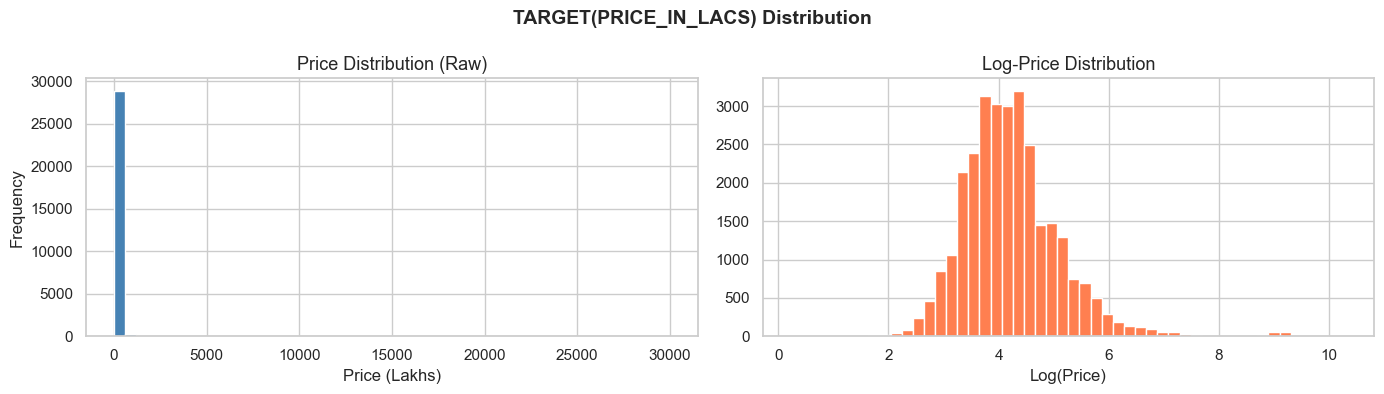

In [8]:
# Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['TARGET(PRICE_IN_LACS)'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution (Raw)', fontsize=13)
axes[0].set_xlabel('Price (Lakhs)')
axes[0].set_ylabel('Frequency')

axes[1].hist(np.log1p(df['TARGET(PRICE_IN_LACS)']), bins=50, color='coral', edgecolor='white')
axes[1].set_title('Log-Price Distribution', fontsize=13)
axes[1].set_xlabel('Log(Price)')

plt.suptitle('TARGET(PRICE_IN_LACS) Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/01_price_distribution.png', dpi=100)
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'plots/06_price_by_bhk.png'

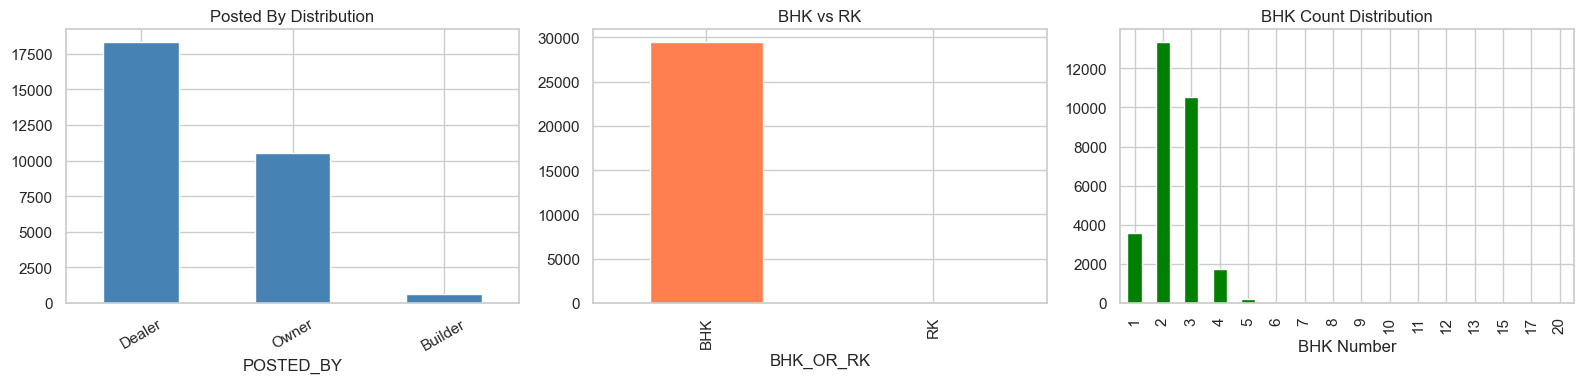

In [9]:
# Categorical feature analysis
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df['POSTED_BY'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Posted By Distribution')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30)

df['BHK_OR_RK'].value_counts().plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('BHK vs RK')

df['BHK_NO.'].value_counts().sort_index().plot(kind='bar', ax=axes[2], color='green', edgecolor='white')
axes[2].set_title('BHK Count Distribution')
axes[2].set_xlabel('BHK Number')

plt.tight_layout()
plt.savefig('plots/06_price_by_bhk.png', dpi=100)
plt.show()

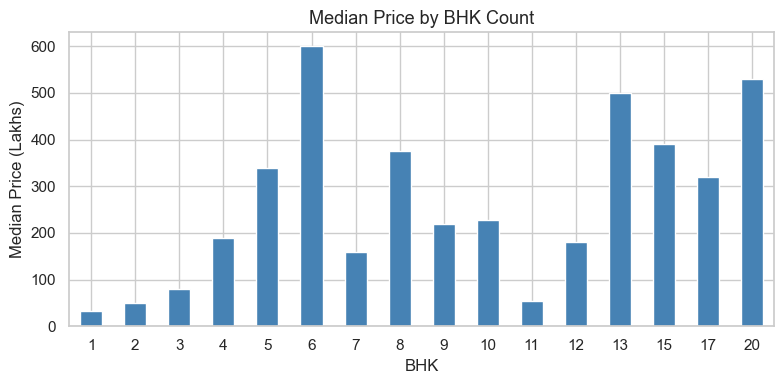

In [10]:
# Median price by BHK
bhk_price = df.groupby('BHK_NO.')['TARGET(PRICE_IN_LACS)'].median()
fig, ax = plt.subplots(figsize=(8, 4))
bhk_price.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Median Price by BHK Count', fontsize=13)
ax.set_xlabel('BHK')
ax.set_ylabel('Median Price (Lakhs)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

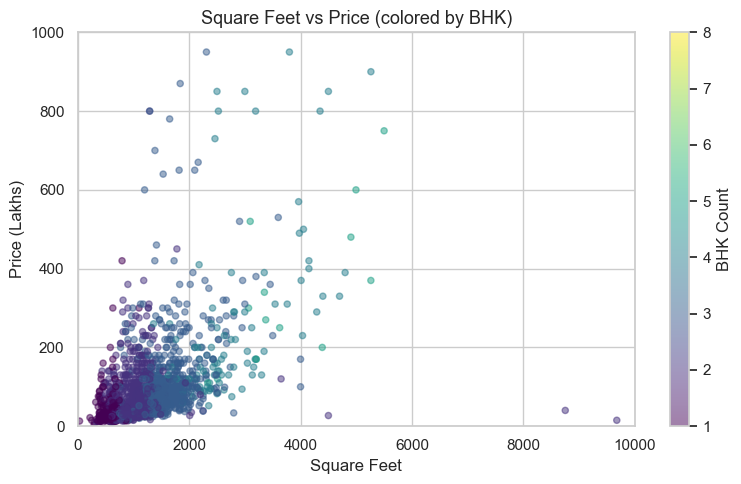

In [11]:
# Scatter: Square Feet vs Price
sample = df.sample(2000, random_state=42)
fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(sample['SQUARE_FT'], sample['TARGET(PRICE_IN_LACS)'],
                c=sample['BHK_NO.'], cmap='viridis', alpha=0.5, s=20)
plt.colorbar(sc, ax=ax, label='BHK Count')
ax.set_title('Square Feet vs Price (colored by BHK)', fontsize=13)
ax.set_xlabel('Square Feet')
ax.set_ylabel('Price (Lakhs)')
ax.set_xlim(0, 10000)
ax.set_ylim(0, 1000)
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

In [12]:
# Remove outliers (top 1%)
Q99 = df['TARGET(PRICE_IN_LACS)'].quantile(0.99)
df = df[df['TARGET(PRICE_IN_LACS)'] <= Q99].copy()
print(f"Shape after outlier removal: {df.shape}")

# Label encode categorical features
le_posted = LabelEncoder()
le_bhkor  = LabelEncoder()
df['POSTED_BY_ENC']  = le_posted.fit_transform(df['POSTED_BY'])
df['BHK_OR_RK_ENC']  = le_bhkor.fit_transform(df['BHK_OR_RK'])

# Extract and encode city
df['CITY'] = df['ADDRESS'].apply(lambda x: x.split(',')[-1].strip() if ',' in x else x.strip())
top_cities = df['CITY'].value_counts().head(20).index
df['CITY_CAT'] = df['CITY'].apply(lambda x: x if x in top_cities else 'Other')
le_city = LabelEncoder()
df['CITY_ENC'] = le_city.fit_transform(df['CITY_CAT'])

print("Encoding complete.")
df[['POSTED_BY','POSTED_BY_ENC','BHK_OR_RK','BHK_OR_RK_ENC','CITY','CITY_ENC']].head(5)

Shape after outlier removal: (29156, 12)
Encoding complete.


,POSTED_BY,POSTED_BY_ENC,BHK_OR_RK,BHK_OR_RK_ENC,CITY,CITY_ENC
0,Owner,2,BHK,0,Bangalore,0
1,Dealer,1,BHK,0,Mysore,17
2,Owner,2,BHK,0,Bangalore,0
3,Owner,2,BHK,0,Ghaziabad,5
4,Dealer,1,BHK,0,Kolkata,9


In [13]:
# Define features and target
features = ['POSTED_BY_ENC','UNDER_CONSTRUCTION','RERA','BHK_NO.','BHK_OR_RK_ENC',
            'SQUARE_FT','READY_TO_MOVE','RESALE','LONGITUDE','LATITUDE','CITY_ENC']
target = 'TARGET(PRICE_IN_LACS)'

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

Train size: (23324, 11), Test size: (5832, 11)


FileNotFoundError: [Errno 2] No such file or directory: 'plots/02_correlation.png'

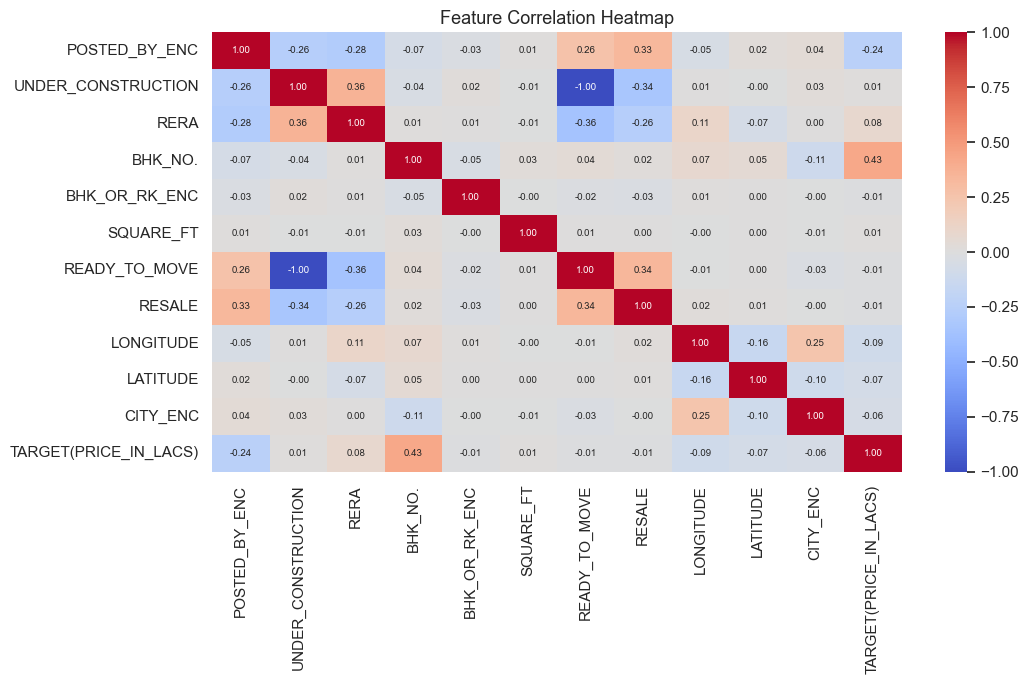

In [14]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(11, 7))
corr = df[features + [target]].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax, annot_kws={'size': 7})
ax.set_title('Feature Correlation Heatmap', fontsize=13)
plt.tight_layout()
plt.savefig('plots/02_correlation.png', dpi=100)
plt.show()

## 5. Model Building & Evaluation

In [15]:
def evaluate(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)
    print(f"{name:<25} MAE: {mae:8.2f}  RMSE: {rmse:8.2f}  R²: {r2:.4f}")
    return {'model': model, 'preds': preds, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

print(f"{'Model':<25} {'MAE':>10}  {'RMSE':>10}  {'R²':>8}")
print("-" * 60)

models = {
    'Linear Regression':    LinearRegression(),
    'Ridge Regression':     Ridge(alpha=10),
    'Random Forest':        RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting':    GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost':              xgb.XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
}

results = {}
for name, model in models.items():
    results[name] = evaluate(name, model, X_train, X_test, y_train, y_test)

Model                            MAE        RMSE        R²
------------------------------------------------------------
Linear Regression         MAE:    54.19  RMSE:    94.34  R²: 0.2556
Ridge Regression          MAE:    54.18  RMSE:    94.34  R²: 0.2556
Random Forest             MAE:    21.69  RMSE:    47.43  R²: 0.8118
Gradient Boosting         MAE:    27.65  RMSE:    53.17  R²: 0.7635
XGBoost                   MAE:    22.28  RMSE:    45.31  R²: 0.8283


FileNotFoundError: [Errno 2] No such file or directory: 'plots/03_model_comparison.png'

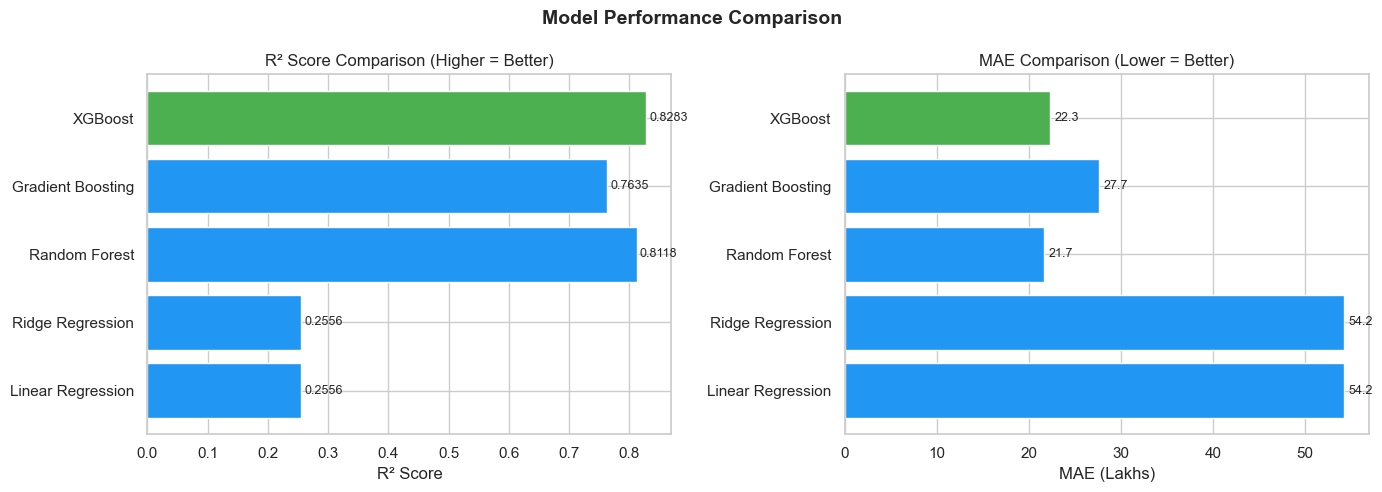

In [16]:
# Model comparison chart
names_list = list(results.keys())
r2s  = [results[n]['R2']  for n in names_list]
maes = [results[n]['MAE'] for n in names_list]
best_name = max(results, key=lambda n: results[n]['R2'])

colors = ['#4CAF50' if n == best_name else '#2196F3' for n in names_list]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(names_list, r2s, color=colors)
axes[0].set_title('R² Score Comparison (Higher = Better)', fontsize=12)
axes[0].set_xlabel('R² Score')
for i, v in enumerate(r2s): axes[0].text(v+0.005, i, f'{v:.4f}', va='center', fontsize=9)

axes[1].barh(names_list, maes, color=colors)
axes[1].set_title('MAE Comparison (Lower = Better)', fontsize=12)
axes[1].set_xlabel('MAE (Lakhs)')
for i, v in enumerate(maes): axes[1].text(v+0.5, i, f'{v:.1f}', va='center', fontsize=9)

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/03_model_comparison.png', dpi=100)
plt.show()
print(f"\nBest Model: {best_name} (R² = {results[best_name]['R2']:.4f})")

FileNotFoundError: [Errno 2] No such file or directory: 'plots/04_actual_vs_predicted.png'

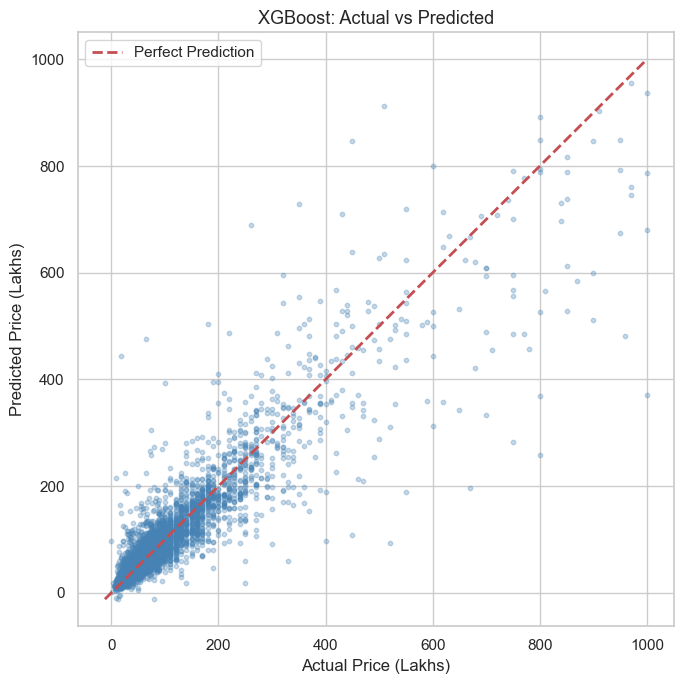

In [17]:
# Actual vs Predicted
best_preds = results[best_name]['preds']
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, best_preds, alpha=0.3, s=10, color='steelblue')
lims = [min(y_test.min(), best_preds.min()), max(y_test.max(), best_preds.max())]
ax.plot(lims, lims, 'r--', lw=2, label='Perfect Prediction')
ax.set_xlabel('Actual Price (Lakhs)')
ax.set_ylabel('Predicted Price (Lakhs)')
ax.set_title(f'{best_name}: Actual vs Predicted', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('plots/04_actual_vs_predicted.png', dpi=100)
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'plots/05_feature_importance.png'

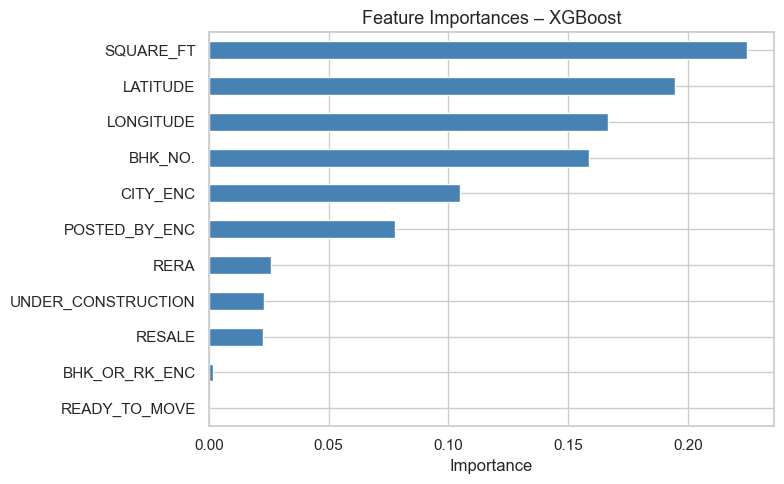

In [18]:
# Feature Importance
best_model = results[best_name]['model']
if hasattr(best_model, 'feature_importances_'):
    imp = pd.Series(best_model.feature_importances_, index=features).sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(8, 5))
    imp.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'Feature Importances – {best_name}', fontsize=13)
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.savefig('plots/05_feature_importance.png', dpi=100)
    plt.show()

## 6. Save Best Model

In [19]:
os.makedirs('plots', exist_ok=True)

# Save the best model
joblib.dump(best_model, 'best_model.pkl')

# Save encoders
joblib.dump({
    'le_posted': le_posted,
    'le_bhkor':  le_bhkor,
    'le_city':   le_city,
    'top_cities': list(top_cities),
    'features':   features
}, 'encoders.pkl')

print(f"Best model saved: {best_name}")
print(f"R²  = {results[best_name]['R2']:.4f}")
print(f"MAE = {results[best_name]['MAE']:.2f} Lakhs")
print(f"RMSE= {results[best_name]['RMSE']:.2f} Lakhs")

Best model saved: XGBoost
R²  = 0.8283
MAE = 22.28 Lakhs
RMSE= 45.31 Lakhs


## 7. Conclusion

- **XGBoost** achieved the best performance with R²≈0.828, MAE≈22 Lakhs.
- Key predictors are **Square Footage**, **Latitude/Longitude** (location), and **BHK count**.
- Linear models underperformed due to non-linear relationships in the data.
- The model is saved as `best_model.pkl` and can be deployed via the Streamlit app (`app.py`).